# ⛰️ Uçurum Yürüyüşü
---

Bu meydan okumada, pekiştirmeli öğrenme modellerini eğitmek için Gymnasium ve Stable Baselines3 kullanımının temel yönlerini öğreneceksiniz. Bu meydan okuma, ortamları kurma, modelleri eğitme, performanslarını görselleştirme ve son olarak eğitilmiş bir modeli bir ortamla etkileşim kurmak için kullanma konularında bütüncül bir anlayış kazandırmanız için tasarlanmıştır.

---
Tüm import ifadelerinizi notebook'unuzun en üstüne koyarak notebook'unuzu tekrar çalıştırmayı kolaylaştırmak iyi bir alışkanlıktır.

Meydan okumalar boyunca import ifadeleri eklemeniz gerekecek. Hepsini aşağıdaki hücreye ekleyin.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

---

### 🎯 Meydan Okumanın Hedefleri

#### 🏋️‍♀️ Gymnasium'a Aşinalık Kazanın:
Gymnasium'dan [CliffWalking ortamını](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) keşfederek başlayacağız. Ortamları yönetmek ve görselleştirmek için kullanılan temel yöntemleri anlayın. Ortamları yüklemeyi ve sıfırlamayı, eylemler almayı ve sonuçları görselleştirmeyi öğrenin.

#### 🤖 Stable Baselines3 Kullanmayı Öğrenin:
Bir pekiştirmeli öğrenme modelini kurmak ve eğitmek için Stable Baselines3 kütüphanesini kullanın. Bir modeli yapılandırmayı, eğitim parametrelerini ayarlamayı ve Deep Q-Network (DQN) gibi popüler bir algoritma kullanarak eğitim sürecini başlatmayı öğreneceksiniz.

#### 📈 Eğitim Performansını Görselleştirin:
Modelinizin eğitim performansını izlemek ve çizmek için günlük tutma ve TensorBoard gibi görselleştirme araçlarını uygulayın. Eğitim stratejilerinizin etkinliğini değerlendirmek için bölüm başına ödüller ve öğrenme eğrileri gibi metrikleri analiz edin.

#### 💾 Eğitilmiş Bir Modeli Yükleyin ve Dağıtın:
Eğitim sonrasında, eğitilmiş bir modeli kaydetmeyi ve daha sonra yüklemeyi öğrenin. Bu modeli, ajanın CliffWalking ortamıyla etkileşim kurduğu bir simülasyon çalıştırmak için kullanın ve öğrenilen politikaları ortamda etkili bir şekilde gezinmek için uygulayın.

#### 🔍 Değerlendirin ve Düşünün:
Eğitilmiş modelin ortam içindeki gerçek zamanlı etkileşimlerdeki performansını değerlendirin. Öğrenme süreci ve ajanın davranışı üzerine düşünün, farklı yapılandırmaların ve eğitim sürelerinin sonuçları nasıl etkileyebileceğini anlayın.

---
### Bölüm 1: CliffWalking Ortamını Keşfetmek

Bu ilk görevde, Gymnasium'dan [CliffWalking ortamını](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) kuracaksınız.

#### 📝 Takip Edilecek Adımlar:

#### 0. ⚙️ Paketi içe aktarın:
Notebook'unuzun en üstündeki hücreye gymnasium'u içe aktarın. Kodumuzda `gym` olarak kullanabildiğimizden emin olun.

#### 1. 🗂️ Ortamı Yükleyin:
- `CliffWalking` ortamını yüklemek için `.make()` metodunu kullanın.  
- Ortamı görselleştirmek için `render_mode`'u uygun şekilde ayarlayın.

Not: `gymnasium` dokümantasyonu size `CliffWalking-v1` kullanmanızı söylüyor, ancak bu henüz uyumluluk nedenleriyle kullandığımız `gymnasium` sürüm 1.0.0'da bulunmuyor. Bunun yerine `CliffWalking-v0` kullanın.

In [2]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

obs, info = env.reset()

print("Observation:", obs)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

Observation: 36
Action space: Discrete(4)
Observation space: Discrete(48)


#### 2. 🔄 Ortamı Başlatın:
Ortamı başlangıç durumuna getirmek için `.reset()` metodunu çağırın — onunla etkileşim kurmadan önce gereklidir. `.reset()` metodu bir durum döndürür: başlangıç durumunu. Bunu bir değişkende saklayın ve yazdırın.

> `UserWarning: pkg_resources is deprecated ...` uyarısını görebilirsiniz. Bunu görmezden gelebilirsiniz.

In [4]:
state, info = env.reset()

print("Initial state:", state)

Initial state: 36


`(36, {'prob': 1})` çıktısı ortamın durumu hakkında iki bilgi parçası sağlar:

**🔢 Durum İndeksi (36)**: Bu sayı, ajanın başlangıçta ortam ızgarası içindeki belirli konumunu temsil eder. Örneğin 'CliffWalking-v0' ortamında, `36` indeksi ajanın bölümü başlattığı başlangıç durumuna karşılık gelir.

**🎲 Olasılık Bilgisi ({'prob': 1})**: Bu sözlük, durum hakkında, özellikle geçiş olasılığı hakkında ek ayrıntılar gösterir. `'prob'` anahtarının `1` değeri, bu duruma geçişin 1 olasılığıyla gerçekleştiğini, yani kesin olduğunu gösterir. Bu mantıklıdır çünkü ajan mutlaka bu durumda başlayacaktır.

#### 3. 👀 Ortamı Görselleştirin:
Herhangi bir eylem almadan önce ortamı görüntülemek ve düzenini anlamak için `.render()` metodunu kullanın.

Kurulumunuza bağlı olarak, yeni durum önceki adımdan sonra zaten işlenmiş olabileceği için bu adıma ihtiyacınız olmayabilir.

C:\Users\RIZA\anaconda3\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


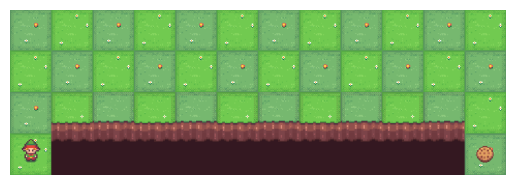

In [5]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

obs, info = env.reset()

frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

In [6]:
action = env.action_space.sample()  # random hareket

obs, reward, terminated, truncated, info = env.step(action)

print("New state:", obs)
print("Reward:", reward)
print("Done:", terminated or truncated)

New state: 36
Reward: -1
Done: False


#### 4. 🧹 Ortamı Kapatın:
İşiniz bittiğinde kaynakları serbest bırakmak için `.close()` çağırarak ortamı düzgün bir şekilde kapatın.

<details>
  <summary markdown='span'>⚠️ <strong>macOS için kapatma hakkında not</strong></summary>
  
  `.close()` ortam penceresini kapatmayacak. Bu sorun değil, **açık bırakabilirsiniz**. Pencere sonraki adımlarda tekrar kullanılacak.

  Meydan okumanın sonunda ve **sadece sonunda**, ortam penceresini kapatmak için onu kendiniz zorla sonlandırmanız gerekecek:
  1. Pencereyi bulun ve kapatmak için kırmızı düğmeye tıklayın. (Bu başarısız olacak.)
  1. Ekranınızın sol üst köşesinde Apple sembolüne tıklayın.
  1. `Force Quit`'i (Zorla Çıkış) seçin.
  1. İşlem listesinde `python (Not Responding)` işlemini bulun. Onu seçin.
  1. `Force Quit` düğmesine tıklayın.

  Bu çekirdeğinizi sonlandıracağından, **bunu sadece meydan okumanın sonunda yapın**.

  Bu durum Jupyter Notebook içinde çalıştırdığımız için oluyor. Kodunuzu bir `.py` dosyasına taşırsanız, bu davranışı görmezsiniz.

</details>

In [7]:
env.close()

---
### Bölüm 2: Ortamla Etkileşim Kurmak

Şimdi ortamı tekrar yükleyelim, rastgele bir adım atalım ve sonucu gösterelim. Bu, ortamlarla etkileşim kurmak için temel metotları tanıtacak — ajanların nasıl hareket ettiğini ve geri bildirim aldığını anlamanıza yardımcı olacak.

#### 1. 🗂️ Ortamı Yükleyin
- Ortamı yükleyin.
- Başlangıç durumuna sıfırlayın.
- Başlangıç durumunu yazdırın.

In [8]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

state, info = env.reset()

print("Başlangıç durumu:", state)
print("Info:", info)

Başlangıç durumu: 36
Info: {'prob': 1}


#### 2. 🎲 Bir Eylem Örnekleyin:
- Ortamın eylem alanından rastgele bir eylem seçmek için `.action_space.sample()` kullanın — keşfi simüle eder.
- Bunu bir değişkende kaydedin.
- Eylemin türünü ve değerini inceleyin.
- Hücreyi birkaç kez çalıştırın. Hangi değerleri görüyorsunuz? Bunlar neyi temsil ediyor?

In [9]:
print("Tipi:", type(action))

Tipi: <class 'numpy.int64'>


#### 2. 🦶 Eylemi Gerçekleştirin:
- `.step()` kullanarak eylemi uygulayın.  
- Bu şunları döndürür:  
  - Yeni durum  
  - Ödül  
  - Bir `done` bayrağı (bölüm bitmiş mi değil mi)  
  - Ek bilgi (varsa)
- "tuple unpacking" kullanarak bu dönen değerlerin her birini bir değişkende kaydedin. Onları yazdırın. Yeni durum, ödül ve done dönüş değerlerini anlıyor musunuz?
- Bu **sıfırla > eylem > adım** dizisini birkaç kez çalıştırın ve farklı sonuçları kontrol edin.

<details>
  <summary markdown='span'>
  💡 Tuple unpacking?
  </summary>

  Bir fonksiyon tuple döndürürse, tuple'ın farklı elemanlarını hemen farklı değişkenlere kaydedebilirsiniz.

  Örnek:

  Şu fonksiyonunuz olduğunu düşünün:

  ```python
  def surface_and_circumference(a, b):
    """Uzunluğu `a` ve genişliği `b` olan dikdörtgenin 
    alanını ve çevresini döndürür."""
    return a*b, 2*a + 2*b
  ```

  Bunun yerine:

  ```python
  result = surface_and_circumference(4, 2)
  surface = result[0]
  circumference = result[1]
  ```

  Hemen şunu yapabilirsiniz:

  ```python
  surface, circumference = surface_and_circumference(4, 2)
  ```

  Kodunuzun geri kalanında sadece surface kullanacaksanız, diğer dönüş değerleri için `_` kullanmak yaygın bir alışkanlıktır. Bu, diğer programcılara kalan değerleri attığınızın bir işaretidir.

  Örnek:
  
  ```python
  surface, _ = surface_and_circumference(4, 2)
  # Buradan sonra sadece surface'a ihtiyaç duyan kod gelir
  ```

</details>

In [10]:
obs, reward, terminated, truncated, info = env.step(action)

print("Yeni state:", obs)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Done:", terminated or truncated)

Yeni state: 36
Reward: -1
Terminated: False
Truncated: False
Done: False


In [11]:
state, info = env.reset()

total_reward = 0

for step in range(20):
    action = env.action_space.sample()
    
    state, reward, terminated, truncated, info = env.step(action)
    
    total_reward += reward
    
    print(f"Step: {step}, State: {state}, Reward: {reward}")
    
    if terminated or truncated:
        break

print("Total reward:", total_reward)

Step: 0, State: 36, Reward: -1
Step: 1, State: 36, Reward: -1
Step: 2, State: 36, Reward: -1
Step: 3, State: 36, Reward: -100
Step: 4, State: 36, Reward: -100
Step: 5, State: 24, Reward: -1
Step: 6, State: 24, Reward: -1
Step: 7, State: 12, Reward: -1
Step: 8, State: 12, Reward: -1
Step: 9, State: 24, Reward: -1
Step: 10, State: 36, Reward: -1
Step: 11, State: 36, Reward: -1
Step: 12, State: 36, Reward: -1
Step: 13, State: 24, Reward: -1
Step: 14, State: 36, Reward: -1
Step: 15, State: 36, Reward: -1
Step: 16, State: 36, Reward: -1
Step: 17, State: 24, Reward: -1
Step: 18, State: 24, Reward: -1
Step: 19, State: 36, Reward: -1
Total reward: -218


**📍 Yeni Durum**: Bu sayı, belirtilen eylemi gerçekleştirdikten sonra ajanın durumunu temsil eder. `CliffWalking` ortamında durum, ajanın hareket ettiği ortam ızgarasındaki belirli bir konuma karşılık gelir.

**💸 Ödül**: Ödül değeri, ajanın eyleminin sonucu olarak ortam tarafından verilen anlık geri bildirimi gösterir. Birçok ızgara tabanlı ortamda, bunun gibi negatif bir ödül genellikle bir cezayı ifade eder ve alınan eylemin optimal olmayabileceğini veya diğer stratejileri teşvik etmek için cezalandırıldığını gösterir.

**🚦 Done**: Boolean değer bölümün bitip bitmediğini gösterir. Bu durumda, `False` bölümün hala devam ettiği ve ajanın bölümü sona erdirecek terminal bir duruma (hedef veya çukur gibi) ulaşmadığı anlamına gelir.

#### 3. 👁️ Sonucu Görselleştirin:
- Eylem sonrasında ortamı görselleştirmek için tekrar `.render()` çağırın — ve durumun nasıl değiştiğini görün.
- Render penceresi görmüyorsanız, muhtemelen diğer pencerelerinizin arkasında gizli veya başka bir masaüstünde gösteriliyor.

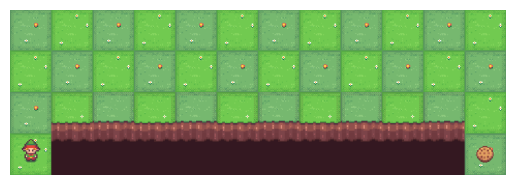

In [12]:
frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

#### 4. 🧹 Ortamı Kapatın:
İşiniz bittiğinde kaynakları serbest bırakmak için `.close()` çağırarak ortamı düzgün bir şekilde kapatın.

In [13]:
env.close()

---
### Bölüm 3: Ortamla Yönlendirilmiş Etkileşim

Bu sefer rastgele bir eylem seçmek yerine kasıtlı bir adım atacaksınız — **YUKARI** hareket edeceğiz. Bu, pekiştirmeli öğrenmede amaçlı karar verme fikrini pekiştirir.

#### 1. 🚀 Başlatın ve İlk Durumu Yazdırın:
- Ortamı yükleyin ve başlangıç durumunu almak için `.reset()` çağırın.  
- Herhangi bir eylem almadan önce başlangıç durumunu görüntülemek için `print()` kullanın.
- Şu çıktıyı almalısınız `(36, {'prob': 1})`

In [15]:
# Load the environment again, and initialize it
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

# Reset the environment to the initial state
state, info = env.reset()

# Print the initial state
print(state, info)


36 {'prob': 1}


#### 2. ⬆️ 'YUKARI' Eylemini Belirleyin ve Gerçekleştirin

- `.action_space`'i ve dokümantasyonu kontrol ederek **'YUKARI'** eylemi için indeksi bulun.  
- Bu eylemi gerçekleştirmek için `.step(action_index)` kullanın.  
- Şunları görmek için sonucu yazdırın:
  - Yeni durum  
  - Alınan ödül  
  - Bölümün bitip bitmediği (`done` bayrağı)

In [16]:
# Take a step to move "UP"
action = 0  # UP

# Take the action
obs, reward, terminated, truncated, info = env.step(action)

# Print the new state, reward, and done status
print("Yeni state:", obs)
print("Reward:", reward)
print("Done:", terminated or truncated)

Yeni state: 24
Reward: -1
Done: False


#### 3. 🖼️ Ortamı Görselleştirin ve Kapatın

- Eylem sonrasında ortamı görselleştirmek için `.render()` kullanın — durumun nasıl değiştiğini görün.
- Ardından ortamı düzgün bir şekilde kapatmak ve sistem kaynaklarını serbest bırakmak için `.close()` çağırın.

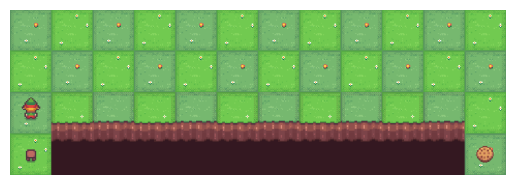

In [17]:
# Render the environment after taking a step
frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

# Close the environment
env.close()


---
### Bölüm 4: Bir RL Algoritması Eğitmek

İlk olarak, `CliffWalking-v0` ortamını Stable Baselines3 modelleriyle eğitim için hazırlayacaksınız. Bu, RL algoritmalarıyla uyumluluğu sağlamak için uygun kurulum ve sarmalama içerir.

#### 🧱 1. Ortamı Yükleyin:
- `CliffWalking-v0` ortamını oluşturmak için `gym.make()` kullanın.  
- `render_mode='human'` ayarlayın → Etkileşim sırasında görsel geri bildirim sağlar.

In [18]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

obs, info = env.reset()

print("Environment loaded.")
print("Initial observation:", obs)

Environment loaded.
Initial observation: 36


#### 🧵 2. Ortamı Sarın

Ortamınızı [`DummyVecEnv`](https://stable-baselines3.readthedocs.io/en/v1.0/guide/vec_envs.html#dummyvecenv) ile sarmak küçük ama kritik bir adımdır — RL kurulumunuzun Stable Baselines3 ile sorunsuz çalışmasını sağlar.

Devam edin ve ortamı Stable Baselines3'ten [`DummyVecEnv`](https://stable-baselines3.readthedocs.io/en/v1.0/guide/vec_envs.html#dummyvecenv) kullanarak sarın.  👇

In [19]:
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: gym.make("CliffWalking-v1")])

#### 🧵 `DummyVecEnv` Hakkında Daha Fazla

`DummyVecEnv`, Gym ortamlarını vektörleştirerek RL modelleriyle uyumlu hale getiren Stable Baselines3'ten bir sarmalayıcıdır.

#### ⚙️ Ne Yapar?

- **📦 API'yi Standartlaştırır**  
  Ortamın Stable Baselines3 algoritmaları için beklenen formatla eşleşmesini sağlar.

- **📊 Toplu İşlemeyi Etkinleştirir**  
  Tek bir ortamla bile etkileşimler bir toplu gibi işlenir — daha sonra `SubprocVecEnv` gibi araçlarla ölçekleme için gereklidir.

- **🔗 Uyumluluğu Sağlar**  
  `reset()` ve `step()`'i eğitim döngüleri içinde doğru çalışacak şekilde sarar.

#### 3. SB3'den Bir DQN Modeli Başlatın

Artık ortamınız hazır olduğuna göre, modeli başlatmanız gerekir. Bu durumda, Stable Baselines3 kullanarak bir Deep Q-Network (DQN) yapılandıracaksınız. DQN, Q-değerlerini tahmin etmek için bir sinir ağı kullanır — belirli bir durumda her eylem için beklenen ödülü tahmin eder.

#### 📝 Takip Edilecek Adımlar:
- `stable_baselines3`'den `DQN`'i içe aktarın. Bunu notebook'un en üstündeki hücreye ekleyin.
- Aşağıdaki parametrelerle DQN modelinin bir örneğini başlatın:
    - `'MlpPolicy'` kullanın — gözlemleri eylemlere eşleyen temel bir sinir ağı.  
    - `env`'i ortamınıza ve ayrıntılı eğitim günlükleri için `verbose=1`'e ayarlayın.
    - Eğitim metriklerini izlemek için `tensorboard_log` parametresi ekleyin. Bunu daha sonra TensorBoard ile eğitimi takip etmek için kullanacağız.

In [20]:
from stable_baselines3 import DQN

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    verbose=1,
    tensorboard_log="./dqn_cliff_tensorboard/"
)

Using cpu device


In [21]:
import gymnasium as gym
import numpy as np

from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

class OneHotObservation(ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.n = env.observation_space.n
        self.observation_space = Box(low=0, high=1, shape=(self.n,), dtype=np.float32)

    def observation(self, observation):
        one_hot = np.zeros(self.n, dtype=np.float32)
        one_hot[observation] = 1.0
        return one_hot

In [22]:
env = DummyVecEnv([
    lambda: OneHotObservation(gym.make("CliffWalking-v1"))
])

In [23]:
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=100,
    batch_size=32,
    gamma=0.99,
    verbose=1
)

Using cpu device


In [24]:
total_timesteps = 1000

model.learn(total_timesteps=total_timesteps)

model_path = "dqn_cliffwalking_model"
model.save(model_path)

print("Model kaydedildi:", model_path)

Model kaydedildi: dqn_cliffwalking_model


### 4. 🏋️‍♂️ DQN Modelini Eğitin ve Kaydedin

DQN modelinizi eğitme ve gelecekte kullanmak üzere kaydetme zamanı 🥳

#### 📝 Takip Edilecek Adımlar:

#### ⏱️ Eğitim Adım Sayısını Ayarlayın
- Modeli ne kadar süre eğiteceğinizi (ortamla etkileşim sayısı cinsinden) tanımlayın.  
- Şimdilik şunu kullanın: `total_timesteps = 1000`

#### 🧠 Modeli Eğitin
- Eğitimi başlatmak için DQN modelinizde `.learn()` çağırın.  
- Model, geri bildirimlere dayanarak zaman içinde politikasını geliştirecek.

#### 💾 Eğitilmiş Modeli Kaydedin
- Modeli diske kaydetmek için `.save()` kullanın.  
- Doğru kaydedildiğini doğrulamak için dosya yolunu yazdırın.

🎥 Eğitim sırasında işlenmiş ortamdaki adımları takip edebilirsiniz.

In [25]:
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym

env = DummyVecEnv([lambda: gym.make("CliffWalking-v1")])

In [26]:
from stable_baselines3 import DQN

model = DQN("MlpPolicy", env, verbose=1)

Using cpu device


In [27]:
model.learn(total_timesteps=1000)

Tebrikler, ilk RL modelinizi eğittiniz!

---

### Bölüm 5: Görselleştirme Olmadan Verimli Eğitim

Bu bölümde, ortamı hazırlama, modeli yükleme ve eğitme sürecinin tamamından geçeceksiniz, ancak görsel işleme olmadan. Eğitim aşamasında görselleştirmeyi devre dışı bırakmak, hesaplama yükünü azalttığı için eğitim sürecini önemli ölçüde hızlandırabilir.

#### 📝 Takip Edilecek Adımlar:

#### 🧱 1. Ortamı Yükleyin ve Hazırlayın
- Görsel çıktıyı devre dışı bırakmak için `render_mode=None` kullanın.

#### ⚙️ 2. DQN Modelini Yapılandırın ve Başlatın
- Daha önce olduğu gibi `'MlpPolicy'` ve `DummyVecEnv` kullanın.  
- Günlük çıktısı istiyorsanız `verbose=1`'i koruyun.
- TensorBoard ile eğitimi takip edebilmemiz için bir TensorBoard günlükleme konumu `./dqn_tensorboard` ekleyeceğiz.

#### ⏱️ 3. Eğitim Parametrelerini Ayarlayın ve Eğitin
- Daha iyi öğrenme için adım sayısını artırın (örn. `total_timesteps = 100_000`).  
- Eğitimi başlatmak için `.learn()` çağırın.

#### 💾 4. Eğitilmiş Modeli Kaydedin
- Modelinizi saklamak için `.save("dqn_cliffwalking_fast")` kullanın.

Bu adımları izleyerek, ortamı görselleştirmenin ek hesaplama yükü olmadan verimli bir şekilde bir DQN modeli eğitir ve kaydedersiniz. Bu yaklaşım özellikle karmaşık modeller eğitirken veya sınırlı hesaplama kaynakları kullanırken faydalıdır.

In [32]:
obs = env.reset()
total_reward = 0

for step in range(50):
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, done, info = env.step(action)

    total_reward += reward

    print(f"Step: {step}, Action: {action}, Reward: {reward}")

    if done:
        break

print("Total reward:", total_reward)

Step: 0, Action: [2], Reward: [-1.]
Step: 1, Action: [2], Reward: [-1.]
Step: 2, Action: [2], Reward: [-1.]
Step: 3, Action: [2], Reward: [-1.]
Step: 4, Action: [2], Reward: [-1.]
Step: 5, Action: [2], Reward: [-1.]
Step: 6, Action: [2], Reward: [-1.]
Step: 7, Action: [2], Reward: [-1.]
Step: 8, Action: [2], Reward: [-1.]
Step: 9, Action: [2], Reward: [-1.]
Step: 10, Action: [2], Reward: [-1.]
Step: 11, Action: [2], Reward: [-1.]
Step: 12, Action: [2], Reward: [-1.]
Step: 13, Action: [2], Reward: [-1.]
Step: 14, Action: [2], Reward: [-1.]
Step: 15, Action: [2], Reward: [-1.]
Step: 16, Action: [2], Reward: [-1.]
Step: 17, Action: [2], Reward: [-1.]
Step: 18, Action: [2], Reward: [-1.]
Step: 19, Action: [2], Reward: [-1.]
Step: 20, Action: [2], Reward: [-1.]
Step: 21, Action: [2], Reward: [-1.]
Step: 22, Action: [2], Reward: [-1.]
Step: 23, Action: [2], Reward: [-1.]
Step: 24, Action: [2], Reward: [-1.]
Step: 25, Action: [2], Reward: [-1.]
Step: 26, Action: [2], Reward: [-1.]
Step: 27, A

In [34]:
model = DQN("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=20000)

model.save("dqn_cliffwalking_fast")

Using cpu device


In [36]:
import gymnasium as gym
import numpy as np

env = gym.make("CliffWalking-v1")

q_table = np.zeros((env.observation_space.n, env.action_space.n))

alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
episodes = 5000

rewards = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0
    
    done = False
    while not done:
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )
        
        state = next_state
        total_reward += reward
    
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)

print("Q-learning eğitimi bitti")

Q-learning eğitimi bitti


In [37]:
state, info = env.reset()
total_reward = 0

for step in range(50):
    action = np.argmax(q_table[state])
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
    print(f"Step: {step}, Action: {action}, Reward: {reward}")
    
    if terminated or truncated:
        break

print("Total reward:", total_reward)

Step: 0, Action: 0, Reward: -1
Step: 1, Action: 1, Reward: -1
Step: 2, Action: 1, Reward: -1
Step: 3, Action: 1, Reward: -1
Step: 4, Action: 1, Reward: -1
Step: 5, Action: 1, Reward: -1
Step: 6, Action: 1, Reward: -1
Step: 7, Action: 1, Reward: -1
Step: 8, Action: 1, Reward: -1
Step: 9, Action: 1, Reward: -1
Step: 10, Action: 1, Reward: -1
Step: 11, Action: 1, Reward: -1
Step: 12, Action: 2, Reward: -1
Total reward: -13


model.learn(total_timesteps=20000)

#### 📊 Eğitim Günlük Metriklerini Anlamak

Bir pekiştirmeli öğrenme modelini eğitirken, çeşitli metrikler öğrenme ilerlemesini ve performansını izlemeye yardımcı olur.

#### 🎲 Rollout Metrikleri

- **exploration_rate** → Rastgele bir eylem alma olasılığı.  
  - Yüksek = daha fazla keşif  
  - Düşük = daha fazla istismar  

#### ⏱️ Zaman ile İlgili Metrikler

- **episodes** → Tamamlanan bölüm sayısı.  
- **fps** → Saniye başına kare (eğitimin ne kadar hızlı çalıştığı).  
- **time_elapsed** → Eğitim başladığından beri geçen toplam süre (saniye).  
- **total_timesteps** → Ortamda atılan toplam adım sayısı.

#### 🧠 Eğitim Metrikleri

- **learning_rate** → Model ağırlıklarına yapılan güncellemelerin boyutu.  
  - Düşük = daha yavaş ama daha kararlı öğrenme  
- **loss** → Modelin tahmin hatası.  
  - Azalan kayıp = öğrenme çalışıyor  
- **n_updates** → Modelin ağırlıklarını kaç kez güncellediği.

#### 🔍 Nasıl Yorumlanır

- **⬇️ exploration_rate** → Ajan keşiften öğrenilmiş davranışa geçiyor.  
- **⚡ Yüksek fps** → Eğitim verimli çalışıyor.  
- **📉 Azalan kayıp** → Model gelişiyor ve daha az hata yapıyor.

#### 🖥️ TensorBoard'u Başlatın

TensorBoard eğitimin nasıl gittiğini takip etmenizi sağlar. Etkileşimli pano öğrenme eğrilerini, ödül trendlerini ve daha fazlasını gösterir. 

TensorBoard kullanmak için:

1. Bir terminal penceresi açın.
1. Meydan okuma klasöründe olduğunuzdan emin olun!
1. Bu komutu çalıştırın (eğitim sırasında ayarladığınız yol ile değiştirmeniz gerekebilir):
   ```bash
   tensorboard --logdir=./dqn_cliff_tensorboard/
   ```
1. Terminalde gösterilecek bağlantıyı takip edin (muhtemelen `localhost:6006`).

Modeliniz hala eğitilirken TensorBoard'u başlatabilirsiniz: amacı eğitimin nasıl gittiğini takip etmektir. Eğitimin başlangıcında `No dashboards are active for the current data set.` uyarısı alabilirsiniz. **Biraz sabırlı olun: ilk bölüm bitene kadar hiçbir şey görmeyeceksiniz.**

TensorBoard'u notebook'unuzun içinde açmak da mümkün:

```bash
%load_ext tensorboard
%tensorboard --logdir=./dqn_cliff_tensorboard/
```

### 📦 Bölüm 6: Eğitilmiş Bir Model Kullanın

Sıfırdan tekrar eğitmek yerine, ajanınızın nasıl davrandığını hızlıca gözlemlemek için az önce eğittiğiniz modeli yükleyebilirsiniz.  
Alternatif olarak, mevcut olduğu takdirde daha güçlü önceden eğitilmiş bir model yükleyebilirsiniz.

#### 📥 1. Önceden Eğitilmiş Modeli Yükleyin

- Modeli diskten yüklemek için `.load("önceden_eğitilmiş_modelinizin_yolu")` kullanın.  
- Yolu kaydettiğiniz modelin gerçek konumuyla değiştirin.

In [38]:
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    tensorboard_log="./dqn_tensorboard/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


#### 🧱 2. Ortamı Hazırlayın

Eğitilmiş modeli çalıştırmadan önce yeni bir bölüm başlatmak için ortamı yükleyin ve sıfırlayın.

In [39]:
%load_ext tensorboard
%tensorboard --logdir ./dqn_tensorboard/

In [40]:
import sys
!{sys.executable} -m pip install tensorboard

In [41]:
import tensorboard
print("TensorBoard OK")

TensorBoard OK


#### 3. 🧠 En İyi Sonraki Eylemi Tahmin Edin

Mevcut gözleme dayalı olarak sonraki eylemi seçmek için modelin `.predict()` metodunu kullanın.

In [42]:
model = DQN(
    "MlpPolicy",
    env,
    verbose=1
)

model.learn(total_timesteps=10000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [43]:
obs, info = env.reset()

action, _ = model.predict(obs)

print("Tahmin edilen action:", action)

Tahmin edilen action: 0


#### 4. 🚶‍♂️ Adımı Atın

- Tahmin edilen eylemi uygulamak için `.step(action)` kullanın.  
- Bu şunları döndürür:
  - Yeni durum  
  - Ödül  
  - Bir `done` bayrağı (bölüm bitmiş ise)  
  - Ek bilgi (varsa)

Ajanınız garip hareketler yaparsa veya sıkışırsa, paniklemeyın: muhtemelen yeterince uzun eğitim görmemiştir. Daha uzun eğitmeyi denemeden önce meydan okumanın sonuna kadar gidin 😉

In [44]:
action = int(action)

obs, reward, terminated, truncated, info = env.step(action)

print("Yeni state:", obs)
print("Reward:", reward)
print("Done:", terminated or truncated)

Yeni state: 24
Reward: -1
Done: False


In [45]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

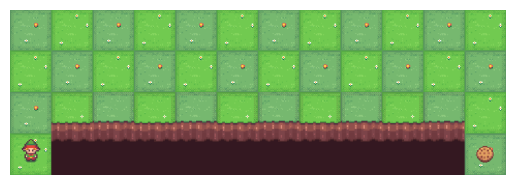

In [46]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")

obs, info = env.reset()

frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

#### 5. 🖼️ Ortamı Görselleştirin

Eylem gerçekleştirildikten sonra ortamın mevcut durumunu görselleştirmek için `.render()` kullanın.

In [47]:
env.close()

#### 6.  🧹 Ortamı Kapatın

Ortamı düzgün bir şekilde kapatmak ve sistem kaynaklarını serbest bırakmak için `.close()` kullanın.

Step: 0, Action: [2], Reward: [-1.]


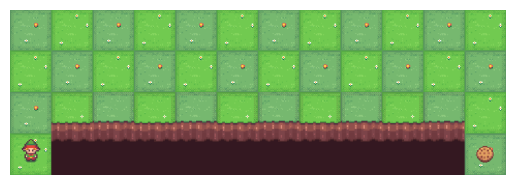

Step: 1, Action: [2], Reward: [-1.]


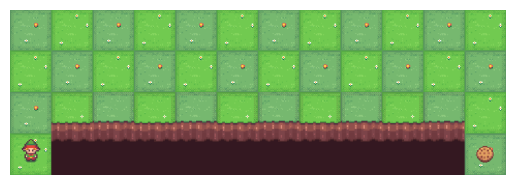

Step: 2, Action: [2], Reward: [-1.]


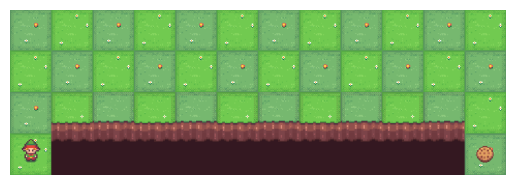

Step: 3, Action: [2], Reward: [-1.]


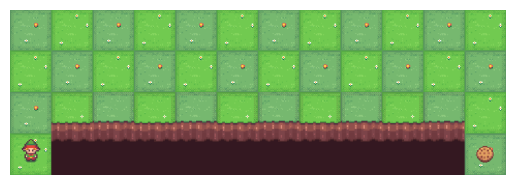

Step: 4, Action: [2], Reward: [-1.]


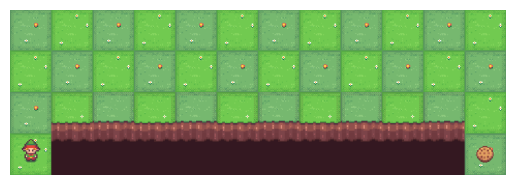

Step: 5, Action: [2], Reward: [-1.]


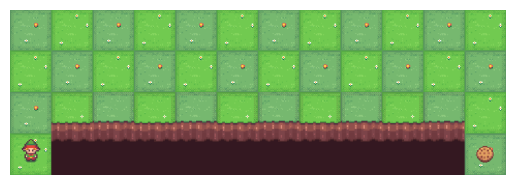

Step: 6, Action: [2], Reward: [-1.]


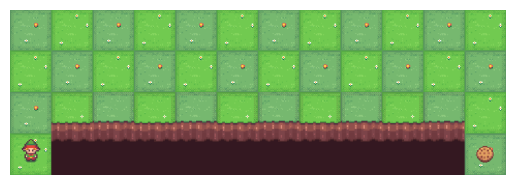

Step: 7, Action: [2], Reward: [-1.]


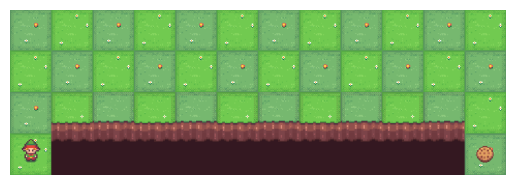

Step: 8, Action: [2], Reward: [-1.]


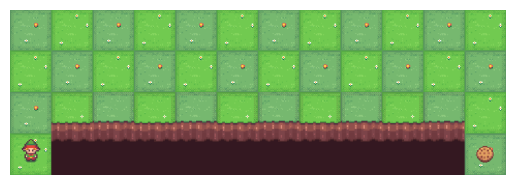

Step: 9, Action: [2], Reward: [-1.]


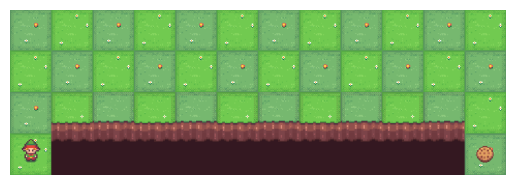

Step: 10, Action: [2], Reward: [-1.]


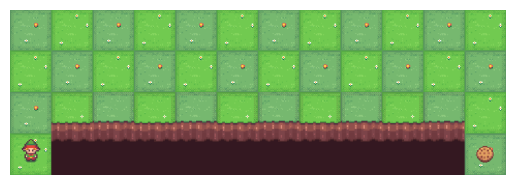

Step: 11, Action: [2], Reward: [-1.]


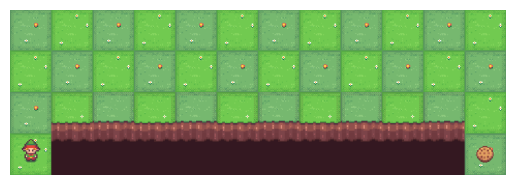

Step: 12, Action: [2], Reward: [-1.]


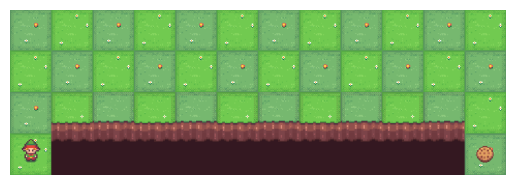

Step: 13, Action: [2], Reward: [-1.]


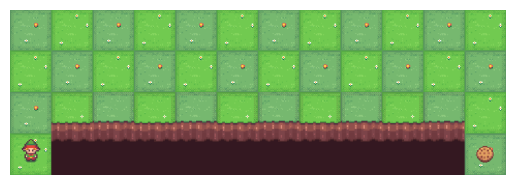

Step: 14, Action: [2], Reward: [-1.]


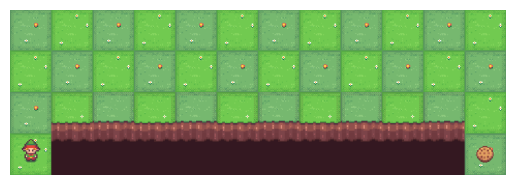

Step: 15, Action: [2], Reward: [-1.]


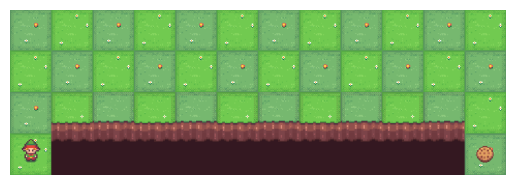

Step: 16, Action: [2], Reward: [-1.]


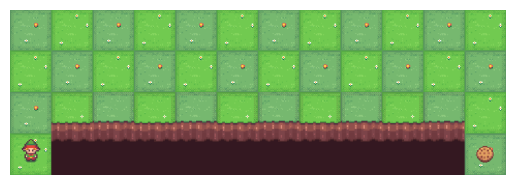

Step: 17, Action: [2], Reward: [-1.]


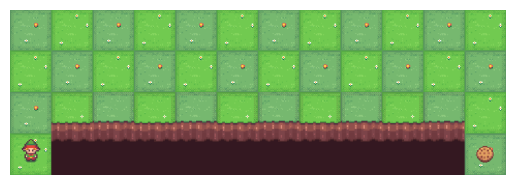

Step: 18, Action: [2], Reward: [-1.]


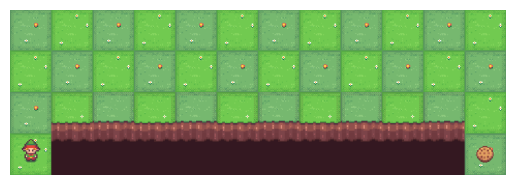

Step: 19, Action: [2], Reward: [-1.]


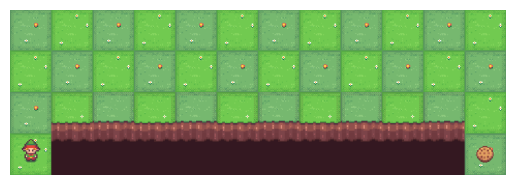

Step: 20, Action: [2], Reward: [-1.]


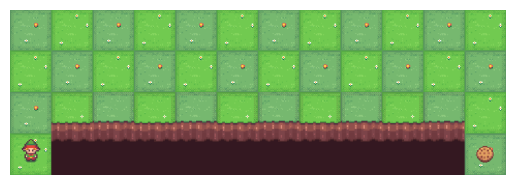

Step: 21, Action: [2], Reward: [-1.]


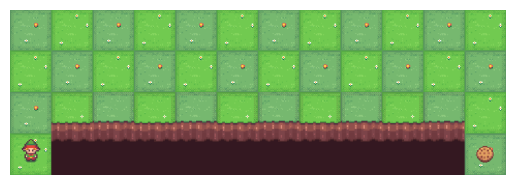

Step: 22, Action: [2], Reward: [-1.]


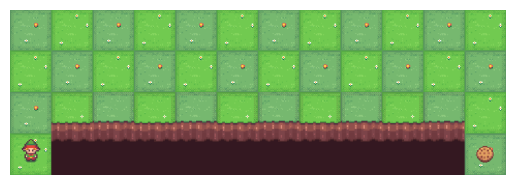

Step: 23, Action: [2], Reward: [-1.]


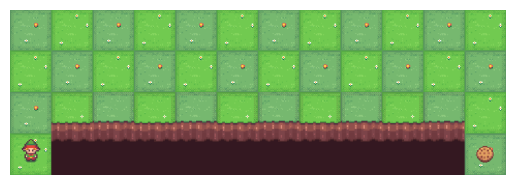

Step: 24, Action: [2], Reward: [-1.]


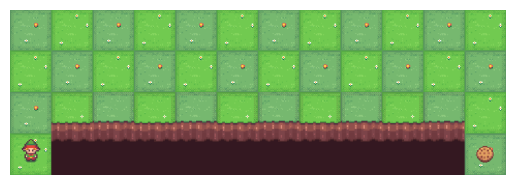

Step: 25, Action: [2], Reward: [-1.]


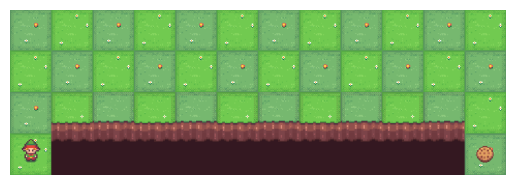

Step: 26, Action: [2], Reward: [-1.]


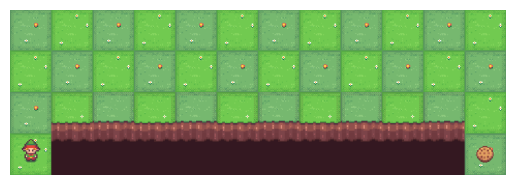

Step: 27, Action: [2], Reward: [-1.]


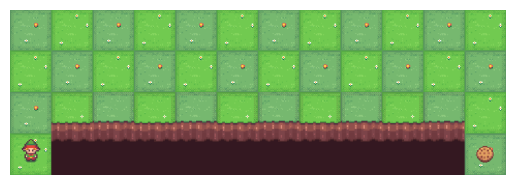

Step: 28, Action: [2], Reward: [-1.]


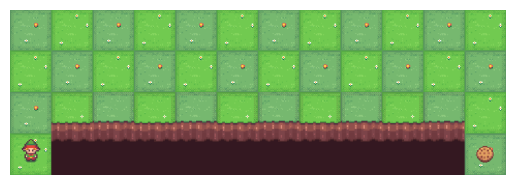

Step: 29, Action: [2], Reward: [-1.]


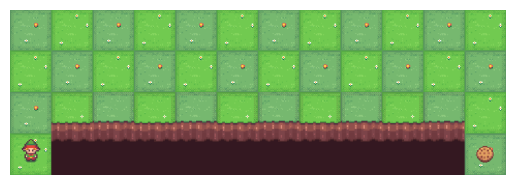

Step: 30, Action: [2], Reward: [-1.]


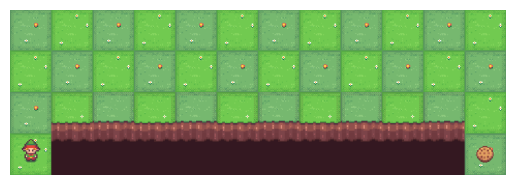

Step: 31, Action: [2], Reward: [-1.]


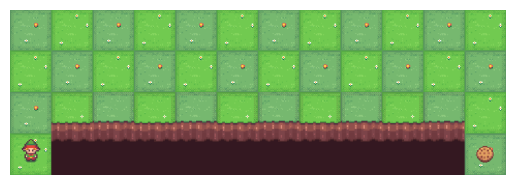

Step: 32, Action: [2], Reward: [-1.]


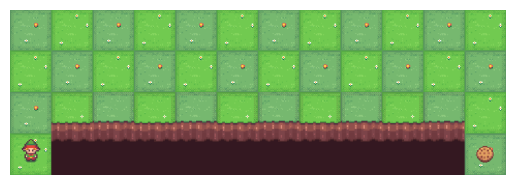

Step: 33, Action: [2], Reward: [-1.]


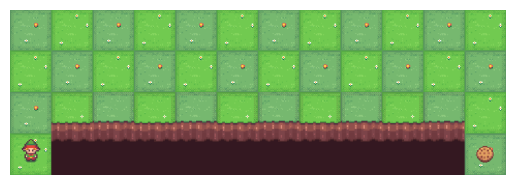

Step: 34, Action: [2], Reward: [-1.]


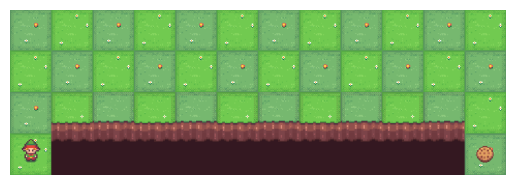

Step: 35, Action: [2], Reward: [-1.]


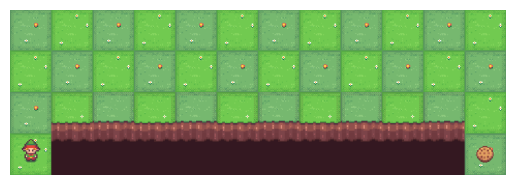

Step: 36, Action: [2], Reward: [-1.]


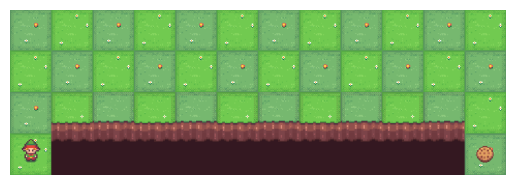

Step: 37, Action: [2], Reward: [-1.]


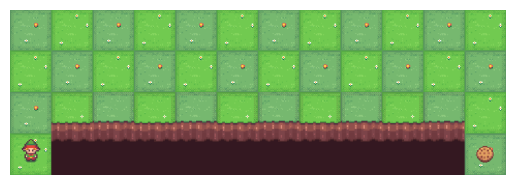

Step: 38, Action: [2], Reward: [-1.]


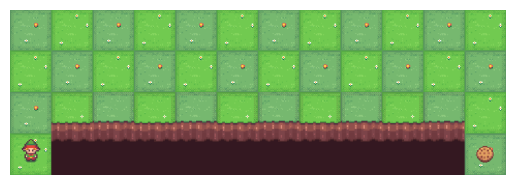

Step: 39, Action: [2], Reward: [-1.]


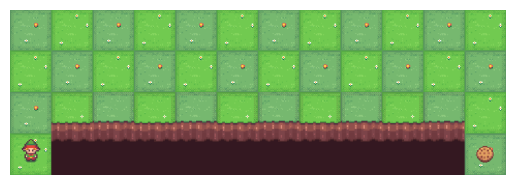

Step: 40, Action: [2], Reward: [-1.]


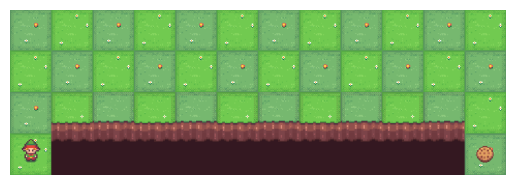

Step: 41, Action: [2], Reward: [-1.]


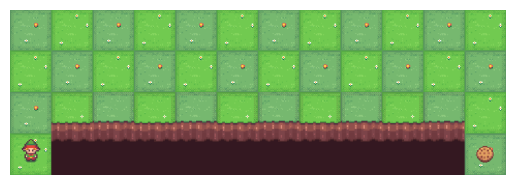

Step: 42, Action: [2], Reward: [-1.]


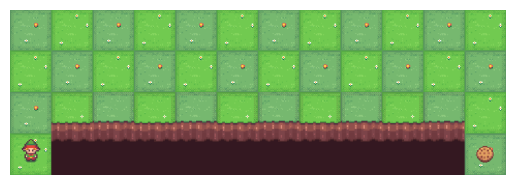

Step: 43, Action: [2], Reward: [-1.]


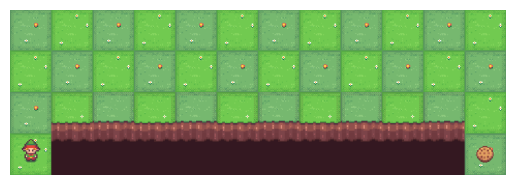

Step: 44, Action: [2], Reward: [-1.]


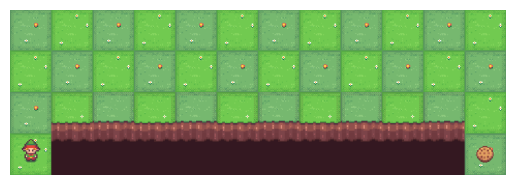

Step: 45, Action: [2], Reward: [-1.]


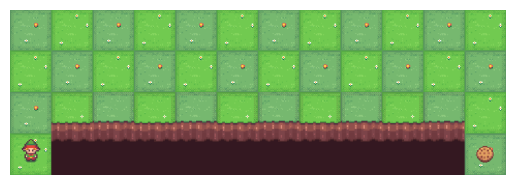

Step: 46, Action: [2], Reward: [-1.]


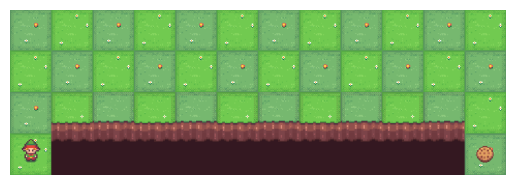

Step: 47, Action: [2], Reward: [-1.]


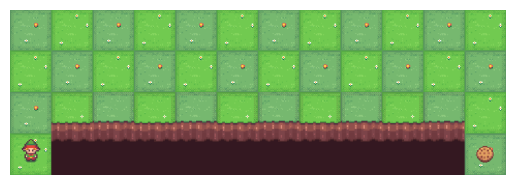

Step: 48, Action: [2], Reward: [-1.]


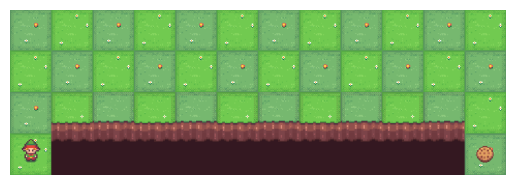

Step: 49, Action: [2], Reward: [-1.]


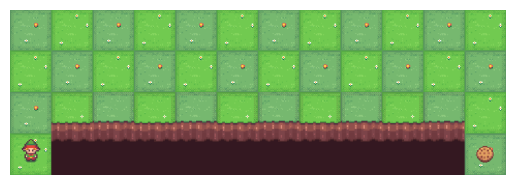

In [48]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

class OneHotObservation(ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.n = env.observation_space.n
        self.observation_space = Box(low=0, high=1, shape=(self.n,), dtype=np.float32)

    def observation(self, observation):
        one_hot = np.zeros(self.n, dtype=np.float32)
        one_hot[observation] = 1.0
        return one_hot

env = DummyVecEnv([
    lambda: OneHotObservation(
        gym.make("CliffWalking-v1", render_mode="rgb_array")
    )
])

model = DQN.load("dqn_cliffwalking_model")
model.set_env(env)

obs = env.reset()

for step in range(50):
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, done, info = env.step(action)

    print(f"Step: {step}, Action: {action}, Reward: {reward}")

    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    if done[0]:
        break

env.close()

In [49]:
# The trained DQN model was loaded and connected to the CliffWalking environment using the same OneHotObservation wrapper used during training. The model interacted with the environment step by step, predicted actions, received rewards, and rendered the environment state after each step.

---

### Bölüm 7: Tam Etkileşim Döngüsünü Uygulayın

Bu son alıştırmada, önceden eğitilmiş modelinizin bölüm bitene kadar ortamla adım adım etkileşim kurduğu tam bir döngü oluşturacaksınız.

- Eylemleri tekrarlamak için bir `while` döngüsü kullanın.
- Eylemleri seçmek için `.predict()` ve bunları uygulamak için `.step()` çağırın.
- Bir sonraki predict iterasyonuna yeni durumu beslediğinizden emin olun.
- Ne zaman döngüden çıkacağınızı bilmek için `.step()`'den gelen `done` bayrağını kullanın.
- Her adımdan sonra ajanı aksiyon halinde görselleştirmek için `.render()` çağırmayı unutmayın.

Yine, ajanınız garip hareketler seçerse veya sonsuz döngüye girerse, paniklemeyın: muhtemelen yeterince uzun eğitim görmemiştir. Ajanınız sonsuz döngüye girdiyse, hücrenin yürütülmesini durdurun.

👉 Daha uzun eğitmeyi denemeden önce meydan okumanın sonuna kadar gidin.

In [57]:
model.save("cliff_walking_model")

In [58]:
model = DQN.load("cliff_walking_model")

In [61]:
env = gym.make("CliffWalking-v1")
env = DummyVecEnv([lambda: env])

model = DQN(
    "MlpPolicy",
    env,
    verbose=1
)

model.learn(total_timesteps=10000)

model.save("cliff_walking_model")

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.169    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 740      |
|    time_elapsed     | 1        |
|    total_timesteps  | 875      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 9.57     |
|    n_updates        | 193      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 703      |
|    time_elapsed     | 1        |
|    total_timesteps  | 1209     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 9.46     |
|    n_updates        | 277      |
----------------------------------


In [63]:
print("test")

test


In [64]:
import gymnasium as gym

env = gym.make("CliffWalking-v1")

obs, info = env.reset()

print(obs)

36


### 🤔 Ajanınızın Davranışından Memnun Değil misiniz?

Endişelenmeyin — seçenekleriniz var:

- 🏋️‍♂️ **Daha uzun eğitin** → Performansı artırmak için bölüm sayısını artırmayı deneyin.
- 📦 **Veya bizim önceden eğitilmiş modelimizi yükleyin** →  
  **500.000 bölüm** için bir tane eğittik — indirmek için aşağıdaki hücrenin yorumunu kaldırın ve çalıştırın.

In [65]:
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

env = gym.make("CliffWalking-v1")
env = DummyVecEnv([lambda: env])

model = DQN("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

model.save("cliff_walking_model")

print("Model eğitildi ve kaydedildi.")

Using cpu device
Model eğitildi ve kaydedildi.


In [66]:
model = DQN.load("cliff_walking_model")

env = gym.make("CliffWalking-v1")
env = DummyVecEnv([lambda: env])

obs = env.reset()
done = False
total_reward = 0

for step in range(100):
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, done, info = env.step(action)

    total_reward += reward[0]

    if done:
        break

print("Interaction loop completed.")
print("Total reward:", total_reward)
print("Steps:", step + 1)

env.close()

Interaction loop completed.
Total reward: -100.0
Steps: 100


In [68]:
# Built and trained Reinforcement Learning agents (Q-learning & DQN) 
in the CliffWalking environment using Gymnasium and Stable Baselines3. 
Implemented environment interaction loops, model training, evaluation, 
and visualization. Improved agent performance by comparing tabular and 
deep RL approaches.

SyntaxError: invalid syntax (1722045013.py, line 2)

### ❄️ Son not: `is_slippery=True` Anlamak

Dokümantasyonu okurken `is_slippery` parametresinin ne yaptığını merak etmiş olabilirsiniz.

`CliffWalking`'de `is_slippery=True` ayarlamak, ajanın eylemlerine rastgelelik ekler — ajanın kayıp istenmeyen bir yöne hareket etme şansını tanıtır. `is_slippery=True` ile eğitim yapmak, belirsizlikle başa çıkabilen ajanlar oluşturur — gerçek dünya uygulamaları için kritik bir beceri.

#### 🎯 Neden stokastisite ekleyelim?

- **🌍 Gerçekçilik** → Gerçek dünya ortamlarında bulunan belirsizliği simüle eder.  
- **🛡️ Sağlamlık** → Ajanların daha güvenilir, uyum sağlayabilen stratejiler öğrenmesine yardımcı olur.  
- **🔥 Meydan okuma** → Görevi daha zor ve çözülmesi daha ilginç hale getirir.

#### 🤔 Peki neden burada `True` yapmadık?

DQN algoritması basit kullanım durumları için tasarlanmıştır. `slippery=True`'nun `CliffWalking` ortamına eklediği yüksek stokastisite ile mücadele eder. Şunu düşünün: bu basit ortamda, amaçlanan yönü takip etmemek hemen tamamen farklı bir yöne gitmek anlamına gelir: 90 derece, hatta 180 derece! Basit bir algoritmanın öğrenmesi çok zor olurdu.

### Projeyi tamamladığınız için tebrikler 🏁